# Overview (Female Candidate)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
# import NominalSurvivalRanker
import ranker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Candidate_Female_Heart.pkl")
# display shape
df.shape

(7589, 133)

## Female

In [3]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 7589 entries, 10 to 28747
Data columns (total 133 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  7589 non-null   category
 1    WaitListDiagnosisCode_CAN                     7589 non-null   category
 2    Gender_CAN                                    7589 non-null   category
 3    BloodGroup_CAN                                7589 non-null   category
 4    Citizenship_CAN                               7589 non-null   category
 5    ResidencyStateRegistration_CAN                7589 non-null   category
 6    EducationLevel_CAN                            7589 non-null   category
 7    LifeSupportRegistration_ECMO_CAN              7589 non-null   category
 8    LifeSupportRegistration_IABP_CAN              7589 non-null   category
 9    LifeSupportInhaled_CAN                    

In [4]:
# Empty DataFrame for record keeping
mapping_df = pd.DataFrame()

#### Previous Transplant Number

In [5]:
# info
features = u.get_feature_info(df, 'PreviousTransplantNumber', cat=False)
# dtype
df[features].apply(lambda s: repr(s.dtype))

                              count  unique  top  freq
PreviousTransplantNumber_CAN   7589       4    0  7209

:::: NaN Count:
PreviousTransplantNumber_CAN    0 



PreviousTransplantNumber_CAN    CategoricalDtype(categories=[0, 1, 2, 3], ordered=True, categories_dtype=int64)
dtype: object

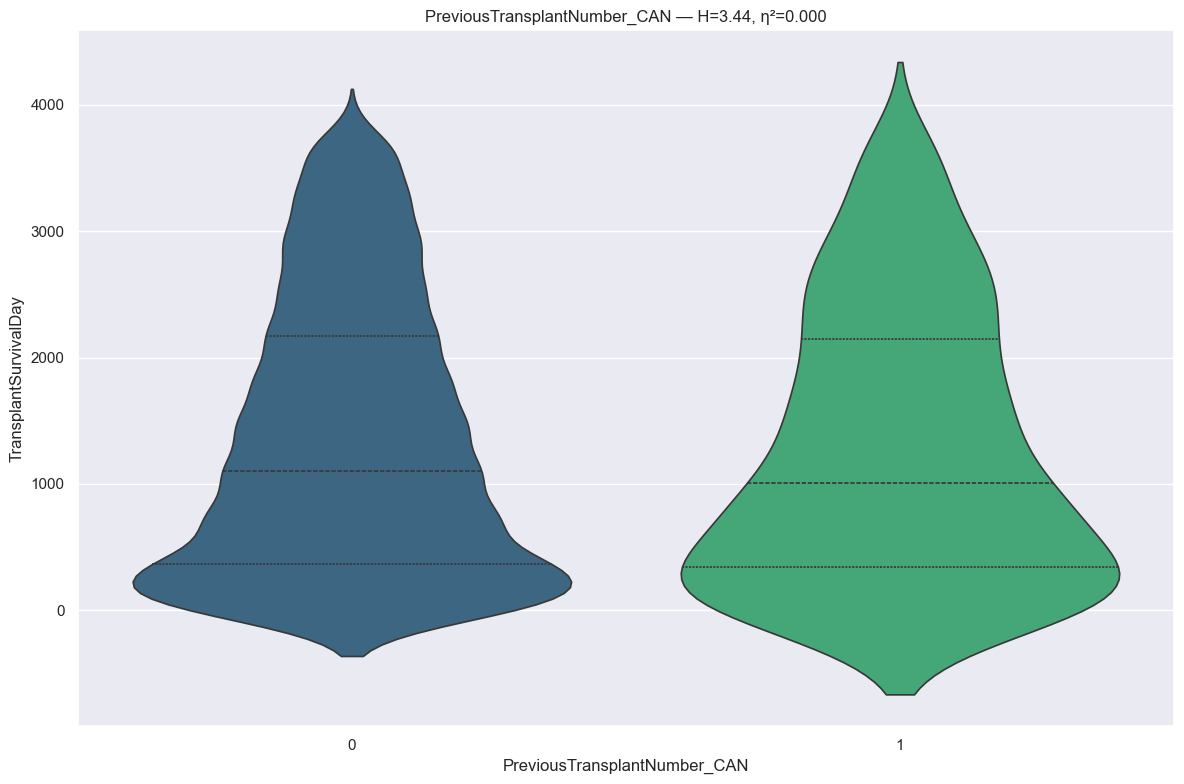

RANKING REPORT: PreviousTransplantNumber_CAN (n ≥ 30)
INCLUDED CATEGORIES:
 * 0                                                 :   7209 records
 * 1                                                 :    352 records
BYPASSED CATEGORIES (n < min_n):
 * 2                                                 :     25 records
 * 3                                                 :      3 records
--------------------------------------------------------------------------------
Kruskal H: 3.4371 | P-value: 6.374928e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
0            vs 1            | p=6.3751e-02 | thr=0.0500 | r=-0.058 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - 0
  - 1

>>> Other (2 categories)
  - 2
  - 3


In [6]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni", # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    "suppress_pairwise": False,
    "plot": True,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_data, results = ranker.cat_feature_ranker(df, mapping_df, 
                       features, class_values, 
                       re_run=False)

In [ ]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni", # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    "suppress_pairwise": False,
    "plot": True,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_data, results = ranker.cat_feature_ranker(df, mapping_df, 
                       features, class_values, 
                       re_run=False)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni", # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# initialize remove list
remove_cols = features

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### WaitList Diagnosis Code

In [ ]:
# info
features = u.get_feature_info(df, 'WaitListDiagnosisCode', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Gender

In [ ]:
# info
features = u.get_feature_info(df, 'Gender', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize remove list
remove_cols.extend(features)

#### Blood Group

In [ ]:
# info
features = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

##### **Note:** Not going to collapse blood types since it is a very important part of transplant

#### Citizenship

In [ ]:
# info
features = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Missing': 'Other',
           'NON-RESIDENT ALIEN': 'Other',
           'RESIDENT ALIEN': 'Other',
           'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant': 'Other',
           'Non-US Citizen/Non-US Resident, Traveled to US for Transplant': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Residency State Registration

In [ ]:
# info
features = u.get_feature_info(df, 'ResidencyStateRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.08,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Residency State Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'ResidencyStateTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Education Level

In [ ]:
# info
features = u.get_feature_info(df, 'EducationLevel', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
    
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

##### Life Support Registration ECMO

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportRegistration_ECMO', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Life Support Registration IABP

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportRegistration_IABP', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Life Support Inhaled

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportInhaledRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Life Support Inhaled Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportInhaledTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Inotropes IV Registration

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesIVRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### LifeSupport Registration PGE

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportRegistration_PGE', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Life Support Mechanism Registration OTHER

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportMechanismRegistration_OTHER', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

#### Ventricular Device Type Registration

In [ ]:
# info
features = u.get_feature_info(df, 'VentricularDeviceTypeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping: Collapse Missing & Unknown into Other
mapping = {'Rvad': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Ventricular Device Brand Registration

In [ ]:
# info
features = u.get_feature_info(df, 'VentricularDeviceBrandRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Primary Payment Registration

In [ ]:
# info
features = u.get_feature_info(df, 'PrimaryPaymentRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Diagnosis At Listing

In [ ]:
# info
features = u.get_feature_info(df, 'DiagnosisAtListing', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Diabetes

In [ ]:
# info
features = u.get_feature_info(df, 'Diabetes', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Dialysis Type Registration

In [ ]:
# info
features = u.get_feature_info(df, 'DialysisTypeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Dialysis Status Unknown': 'Other',
           'Dialysis - Unknown Type was performed': 'Other',
           'Missing': 'Other', 'Peritoneal Dialysis': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.15, # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Cerebro Vascular Disease

In [ ]:
# info
features = u.get_feature_info(df, 'CerebroVascularDisease', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Previous Malignancy

In [ ]:
# info
features = u.get_feature_info(df, 'PreviousMalignancy', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Defibrillator Implant Registration

In [ ]:
# info
features = u.get_feature_info(df, 'DefibrillatorImplantRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

#### Inotropes Vasodilators Registration SYS

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_SYS', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Inotropes Vasodilators Registration DIA

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_DIA', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Inotropes Vasodilators Registratio MN

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_MN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Inotropes Vasodilators Registration PCW

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_PCW', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list/
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Inotropes Vasodilators Registration CO

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsRegistration_CO', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Cigarette Use

In [ ]:
# info
features = u.get_feature_info(df, 'CigaretteUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Cigarette Abstinence

In [ ]:
# info
features = u.get_feature_info(df, 'CigaretteAbstinence', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

#### Prior Cardiac Surgery

In [ ]:
# info
features = u.get_feature_info(df, 'PriorCardiacSurgery_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Prior Cardiac Surgery Type

In [ ]:
# info
features = u.get_feature_info(df, 'PriorCardiacSurgeryType', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    rotation=90
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Received Deceased Donor Tramsplant

In [ ]:
# info
features = u.get_feature_info(df, 'ReceivedDeceasedDonorTramsplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

#### Status At Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'StatusAtTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    rotation=45,
    suppress_pairwise=True
    
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Life Support Registration

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportRegistration_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Ethnicity

In [ ]:
# info
features = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Ventilator Registration

In [ ]:
# info
features = u.get_feature_info(df, 'VentilatorRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Transplant Region

In [ ]:
# info
features = u.get_feature_info(df, 'TransplantRegion', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate classc(more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

##### Work Income Registration

In [ ]:
# info
features = u.get_feature_info(df, 'WorkIncomeRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen BW4

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenBW4', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen BW6

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenBW6', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen C1

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenC1', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen C2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenC2', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen DR51

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR51_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'2': 'Other',
           '4': 'Other',
           '5': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen DR51 2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR51_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'1': 'Other',
           '3': 'Other',
           '2': 'Other',
           '5': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# mapping
mapping = {'Not Done': 'Other'}
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen DR52

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR52_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'7': 'Other',
           '3': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'1': 'Other',
           '2': 'Other',
           '5': 'Other',
           '4': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen DR52 2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR52_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'5': 'Other',
           '3': 'Other',
           '4': 'Other',
           '7': 'Other',
           '1': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen DR53

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR53_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'1': 'Other',
           '2': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### AntigenDR 53 2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDR53_2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'3': 'Other',
           '2': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Antigen DQ1

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDQ1_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen DQ2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenDQ2_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Medical Condition Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'MedicalConditionTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Primary Payment Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'PrimaryPaymentTransplant_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Life Support Transplant ECMO

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportTransplant_ECMO', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Work Income Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'WorkIncomeTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Life Support Transplant PGE

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportTransplant_PGE', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Dialysis Between Registration Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'DialysisBetweenRegistrationTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### LifeSupportTransplant IABP

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportTransplant_IABP', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Infection Therapy IV

In [ ]:
# info
features = u.get_feature_info(df, 'InfectionTherapyIV', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes IV Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesIVTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes Vasodilators Transplant CO

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_CO', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes Vasodilators Transplant DIA

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_DIA', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes Vasodilators Transplant MN

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_MN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes Vasodilators Transplant PCW

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_PCW', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Inotropes Vasodilators Transplant SYS

In [ ]:
# info
features = u.get_feature_info(df, 'InotropesVasodilatorsTransplant_SYS', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Life Support Mechanism Transplant OTHER

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportMechanismTransplant_OTHER', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Prior Lung Surgery After Registration

In [ ]:
# info
features = u.get_feature_info(df, 'PriorLungSurgeryAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Steroids Use

In [ ]:
# info
features = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Transfusion After Registration

In [ ]:
# info
features = u.get_feature_info(df, 'TransfusionAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Ventricular Device Type Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'VentricularDeviceTypeTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Ventricular Device Brand Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'VentricularDeviceBrandTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Ventilatory Support

In [ ]:
# info
features = u.get_feature_info(df, 'VentilatorySupport', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Ventilator Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'VentilatorTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Prior Cardiac Surgery Type List And Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'PriorCardiacSurgeryTypeListAndTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Hepatitis B CoreAntibody

In [ ]:
# info
features = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Surface Antigen HEP B

In [ ]:
# info
features = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Surface HBV Antibody Total Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'SurfaceHBVAntibodyTotalTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### CMV Status Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'CMVStatus_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### HIV Sero Status Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'HIV_SeroStatusTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### HEP C Serostatus Status

In [ ]:
# info
features = u.get_feature_info(df, 'HEP_C_SerostatusStatus', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Epstein Barr Sero Status Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'EpsteinBarrSeroStatusTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### HIV NAT Pre Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'HIV_NAT_PreTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### HCV_NAT_PreTranspant

In [ ]:
# info
features = u.get_feature_info(df, 'HCV_NAT_PreTranspant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### HBV NAT Result

In [ ]:
# info
features = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Life Support Inhaled Registration

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportInhaledRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Previous Transplant Same Organ

In [ ]:
# info
features = u.get_feature_info(df, 'PreviousTransplantSameOrgan', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Previous Transplant Any Organ

In [ ]:
# info
features = u.get_feature_info(df, 'PreviousTransplantAnyOrgan', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging),
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Antigen RA1

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRA1', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen RA2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRA2', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen RB1

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRB1', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.08, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen RB2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRB2', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen RDR1

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRDR1', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Antigen RDR2

In [ ]:
# info
features = u.get_feature_info(df, 'AntigenRDR2', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Malignancy Between Registration Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'MalignancyBetweenRegistrationTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### CMV IGG Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'CMV_IGG_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Not Done': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### CMV IGM Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'CMV_IGM_Transplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Transplant Type

In [ ]:
# info
features = u.get_feature_info(df, 'TransplantType', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Primary Diagnosis Type

In [ ]:
# info
features = u.get_feature_info(df, 'PrimaryDiagnosisType', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True,
    rotation=45
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.08, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

#### Dialysis Prior Registration

In [ ]:
# info
features = u.get_feature_info(df, 'DialysisPriorRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Life Support Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'LifeSupportTransplant_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Prior Cardiac Surgery List And Transplant

In [ ]:
# info
features = u.get_feature_info(df, 'PriorCardiacSurgeryListAndTransplant', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Malignancy

In [ ]:
# info
features = u.get_feature_info(df, r'^Malignancy_CAN', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Ventilatory Support After Registration

In [ ]:
# info
features = u.get_feature_info(df, 'VentilatorySupportAfterRegistration', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Heart Procedure Type

In [ ]:
# info
features = u.get_feature_info(df, 'HeartProcedureType', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=False,
    plot=True
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

#### Transplant Year

In [ ]:
# info
features = u.get_feature_info(df, 'TransplantYear', cat=False)
# dtype
{col: df[col].dtype for col in features}

In [ ]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)

# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [ ]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

In [ ]:
# add to remove list
remove_cols.extend(features)
# info
df.info(max_cols=df.shape[1])

In [ ]:
# removed all unused categories
for col in df.select_dtypes(include="category"):
    df[col] = df[col].cat.remove_unused_categories()
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [ ]:
# save data: heart dataset
u.write_to_file(df, 'Male_CAN_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Male_CAN_Category_Mapping',path='../Data/', format='pkl')